# TVF playground

Build a patterned layer with the **real metarcwa pipeline** and visualize the
**Tangent Vector Field** (`metarcwa.solver.tvf.TVF`) across all four methods.

Pipeline (no from-scratch geometry — uses the project adapters):

```
metashapes.Shape ──from_metashapes──▶ shape_fn ┐
dispertorch material ─from_dispertorch─▶ eps_fn ┼─▶ Layer ─▶ Stack ─▶ spec().layer_eps ─▶ TVF
                                                ┘
```

| method | reference | output |
|---|---|---|
| `"Jones"` | Antos 2009 | smooth complex Jones field |
| `"Pol"` | S4 | globally-normalised real field |
| `"Normal"` | Schuster 2007 | elementwise unit real field |
| `"Jones_direct"` | FMMax | Jones field from filtered gradient (no optimisation) |

`layer_eps` has shape `[N_layers, N_wl, Ny, Nx]` (axis -2 = Ny↔a2↔y, axis -1 = Nx↔a1↔x).

In [1]:
import sys, os, math
sys.path.insert(0, os.path.abspath("src"))  # repo uses a src/ layout (not pip-installed)

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

from metashapes.shape import Ellipse, Cross, Star, Rectangle
from dispertorch import material, list_materials, ConstantEps

from metarcwa.model.lattice import Lattice
from metarcwa.model.layer import Layer
from metarcwa.model.stack import Stack
from metarcwa.model.utils import from_metashapes, from_dispertorch
from metarcwa.solver.tvf import TVF

print("materials:", sorted(list_materials().keys()))

materials: ['Ag', 'Al', 'Au', 'Cu', 'Si3N4', 'SiO2', 'TiO2', 'aSi', 'cSi']


## Structure parameters

All lengths in nm. Swap the `shape` for any metashapes primitive
(`Ellipse`, `Cross`, `Star`, `Rectangle`, ...) and `solid`/`void` for any
`dispertorch` material or `ConstantEps`.

In [16]:
P = 400.0                 # square period (nm)
GRID = (128, 128)         # (Nx, Ny) real-space sampling
M, N = 20, 20               # Fourier truncation: |m|<=M (a1), |n|<=N (a2)
WL = 632.0                # wavelength (nm)

# Geometry (metashapes) — an anisotropic, rotated ellipse makes the TVF interesting
shape = Rectangle(center=torch.tensor([P / 2, P / 2]),
                size=torch.tensor([150.0, 90.0]),
                angle=torch.tensor(0.0))

# Materials (dispertorch): crystalline-Si inclusion in air
solid = material("aSi")
void  = ConstantEps(1.0)

## Build the layer eps with the adapters

`from_metashapes` → `shape_fn(lattice, nx, ny)` (soft, differentiable mask);
`from_dispertorch` → `eps_fn(wavelength)`. A `Layer` blends them, a `Stack`
rasterizes at `WL`, and `spec().layer_eps` is the complex permittivity grid.

eps_grid (1, 128, 128) torch.complex64 | Re(eps) in [1.00, 17.45]


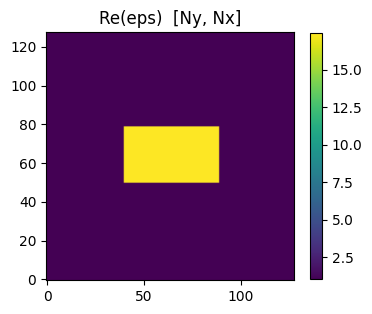

In [17]:
def build_eps(lattice):
    """Return (eps_grid [N_wl, Ny, Nx] complex, a1, a2) for the configured shape/materials."""
    layer = Layer(
        eps_solid_fn=from_dispertorch(solid),
        thickness=torch.tensor(200.0),
        eps_void_fn=from_dispertorch(void),
        shape_fn=from_metashapes(shape, soft=False, softness=1.0),
    )
    stack = Stack(
        incidence=from_dispertorch(ConstantEps(1.0)),
        layers=[layer],
        transmission=from_dispertorch(solid),
        lattice=lattice,
        grid_shape=GRID,
    )
    spec = stack.spec(torch.tensor([WL]))
    return spec.layer_eps[0], spec.a1, spec.a2   # layer 0 -> [N_wl, Ny, Nx]

lattice = Lattice.rectangular(P, P)
eps_grid, a1, a2 = build_eps(lattice)
print("eps_grid", tuple(eps_grid.shape), eps_grid.dtype,
      "| Re(eps) in [%.2f, %.2f]" % (eps_grid.real.min(), eps_grid.real.max()))

plt.figure(figsize=(4, 4))
plt.imshow(eps_grid[0].real.cpu(), origin="lower", cmap="viridis")
plt.title("Re(eps)  [Ny, Nx]"); plt.colorbar(shrink=0.8); plt.show()

## Visualization helpers

`plot_tvf` overlays a vector quiver (real part) on `Re(eps)`; `plot_jones_ellipses`
draws the **polarization ellipse** at each point — the curve traced by
`Re[(Tx, Ty)·e^{iθ}]` over `θ∈[0,2π)`. Complex (Jones) fields give true ellipses;
real fields (`Pol`, `Normal`) degenerate to line segments (linear polarization).
Both map the fractional grid to Cartesian via `lattice.to_cartesian` so oblique
cells render correctly.

In [4]:
def _cart_grid(Ny, Nx, lattice):
    dt = lattice.dtype
    f1 = torch.arange(Nx, dtype=dt) / Nx          # a1 / x  (cols, axis -1)
    f2 = torch.arange(Ny, dtype=dt) / Ny          # a2 / y  (rows, axis -2)
    F2, F1 = torch.meshgrid(f2, f1, indexing="ij")
    X, Y = lattice.to_cartesian(F1, F2)
    return X.cpu().numpy(), Y.cpu().numpy()

def plot_tvf(eps2d, Tx, Ty, lattice, *, title="", step=4, ax=None):
    eps_np = eps2d.real.detach().cpu().numpy()
    Ny, Nx = eps_np.shape
    X, Y = _cart_grid(Ny, Nx, lattice)
    U = Tx.real.detach().cpu().numpy()
    V = Ty.real.detach().cpu().numpy()
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    ax.pcolormesh(X, Y, eps_np, shading="auto", cmap="viridis", alpha=0.85)
    s = (slice(None, None, step), slice(None, None, step))
    ax.quiver(X[s], Y[s], U[s], V[s], color="white",
              angles="xy", pivot="mid", scale=30, width=0.004)
    ax.set_aspect("equal"); ax.set_title(title)
    ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)")
    return ax

def plot_jones_ellipses(eps2d, Tx, Ty, lattice, *, step=6, n_theta=48,
                        fill_frac=0.45, ax=None, title=""):
    """Polarization-ellipse map. Each subsampled point draws the curve
    Re[(Tx,Ty)e^{i theta}]; colour encodes handedness (sign of Stokes S3)."""
    eps_np = eps2d.real.detach().cpu().numpy()
    Ny, Nx = eps_np.shape
    X, Y = _cart_grid(Ny, Nx, lattice)
    jx = Tx.detach().cpu().numpy().astype(np.complex128)
    jy = Ty.detach().cpu().numpy().astype(np.complex128)

    s = (slice(None, None, step), slice(None, None, step))
    cx, cy = X[s].ravel(), Y[s].ravel()
    jxs, jys = jx[s].ravel(), jy[s].ravel()

    # Cartesian point spacing -> ellipse scale (so the largest fits ~fill_frac of a cell)
    a1 = lattice.a1.detach().cpu().numpy(); a2 = lattice.a2.detach().cpu().numpy()
    spacing = step * min(np.linalg.norm(a1) / Nx, np.linalg.norm(a2) / Ny)
    mag = np.sqrt(np.abs(jxs) ** 2 + np.abs(jys) ** 2)
    scale = fill_frac * spacing / (mag.max() if mag.max() > 0 else 1.0)

    th = np.linspace(0, 2 * np.pi, n_theta)
    cos, sin = np.cos(th)[None, :], np.sin(th)[None, :]
    ex = jxs.real[:, None] * cos - jxs.imag[:, None] * sin     # Re(Jx e^{i th})
    ey = jys.real[:, None] * cos - jys.imag[:, None] * sin
    px = cx[:, None] + scale * ex
    py = cy[:, None] + scale * ey
    segs = np.stack([px, py], axis=-1)                         # [P, n_theta, 2]

    s3 = 2.0 * (jxs.real * jys.imag - jxs.imag * jys.real)     # Stokes S3 ~ Im(conj(Jx)Jy)
    colors = np.where(s3 >= 0, "#ff4d4d", "#3aa0ff")

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    ax.pcolormesh(X, Y, eps_np, shading="auto", cmap="gray_r", alpha=0.6)
    ax.add_collection(LineCollection(segs, colors=colors, linewidths=1.0))
    ax.set_aspect("equal"); ax.autoscale_view()
    ax.set_title(title); ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)")
    ax.legend([Line2D([0], [0], color="#ff4d4d"), Line2D([0], [0], color="#3aa0ff")],
              ["S3 > 0", "S3 < 0"], loc="upper right", fontsize=8, framealpha=0.7)
    return ax

## Compare Pol and Normal methods (rectangular lattice)

OutOfMemoryError: CUDA out of memory. Tried to allocate 1.64 GiB. GPU 0 has a total capacity of 23.52 GiB of which 354.12 MiB is free. Including non-PyTorch memory, this process has 23.15 GiB memory in use. Of the allocated memory 19.07 GiB is allocated by PyTorch, and 3.59 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

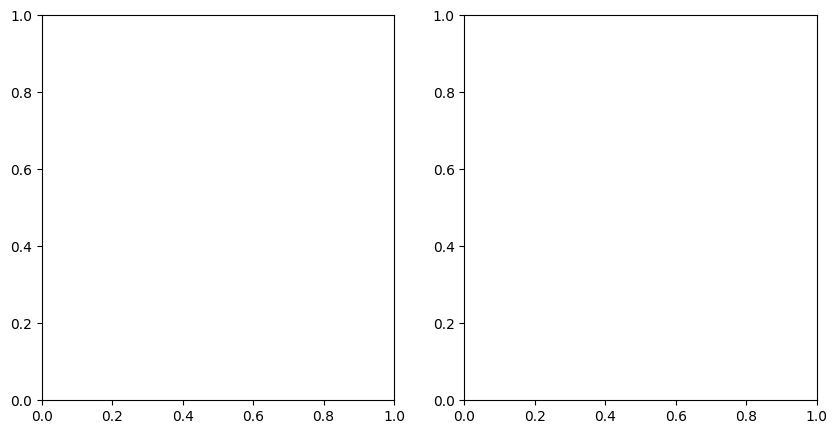

In [19]:
METHODS = ["Pol", "Normal"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, method in zip(axes.ravel(), METHODS):
    tvf = TVF(a1, a2, M=M, N=N, method=method, optimizer="newton")
    Tx, Ty = tvf.compute(eps_grid.to(device='cuda'), alpha=1.0, beta=0.0, gamma=0.05, steps=1)
    plot_tvf(eps_grid[0], Tx[0], Ty[0], lattice, title=method, ax=ax, step=4)
fig.suptitle("TVF by method — rectangular lattice (cSi ellipse in air)", y=1.0, fontsize=14)
plt.tight_layout(); plt.show()

## Polarization-ellipse view (Jones methods)

The complex `"Jones"` and `"Jones_direct"` fields carry phase between the x and y
components, so each point is a polarization ellipse. Each row shows one method:
left = quiver of the real part; right = ellipse map (colour = handedness via Stokes S3).

`Jones` optimises toward a complex Jones target starting from a real initial field,
then applies `normalize_jones` to the result.  
`Jones_direct` starts the optimiser from the full complex Jones field (FMMax convention),
so it converges faster and the output phase is already embedded in the optimised field.

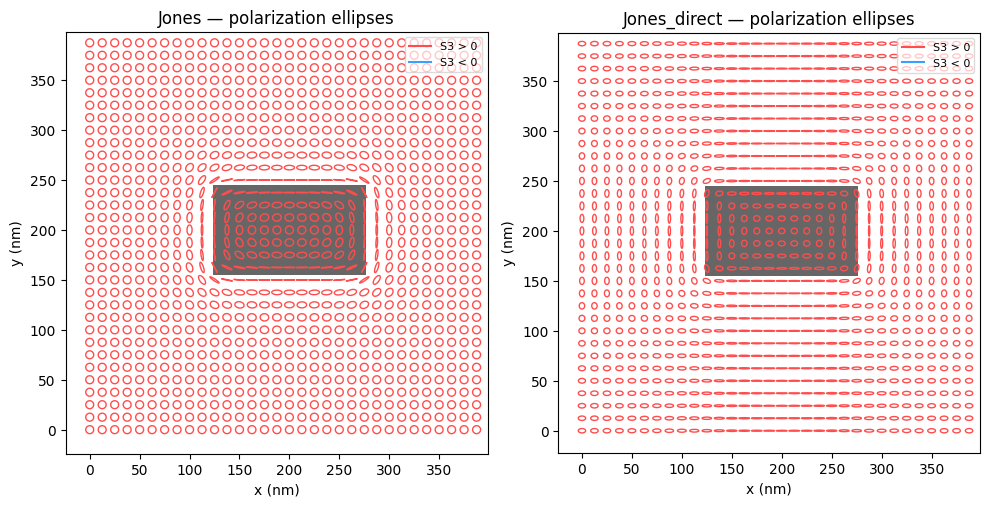

In [13]:
jones_methods = ["Jones", "Jones_direct"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for row, method in enumerate(jones_methods):
    tvf = TVF(a1, a2, M=M, N=N, method=method, optimizer="newton")
    Jx, Jy = tvf.compute(eps_grid.to(device='cuda'), alpha=1.0, beta=0.0005, gamma=0.0, steps=1)
    # plot_tvf(eps_grid[0], Jx[0], Jy[0], lattice,
    #          title=f"{method} — vector (Re)", ax=axes[row, 0])
    plot_jones_ellipses(eps_grid[0], Jx[0], Jy[0], lattice, step=4,
                        title=f"{method} — polarization ellipses", ax=axes[row])
plt.tight_layout(); plt.show()

## Oblique lattice (hexagonal)

Exactly the same `build_eps`, just a hexagonal `Lattice`. The metashapes
rasterizer + `to_cartesian` mapping keep everything correct on the sheared cell.

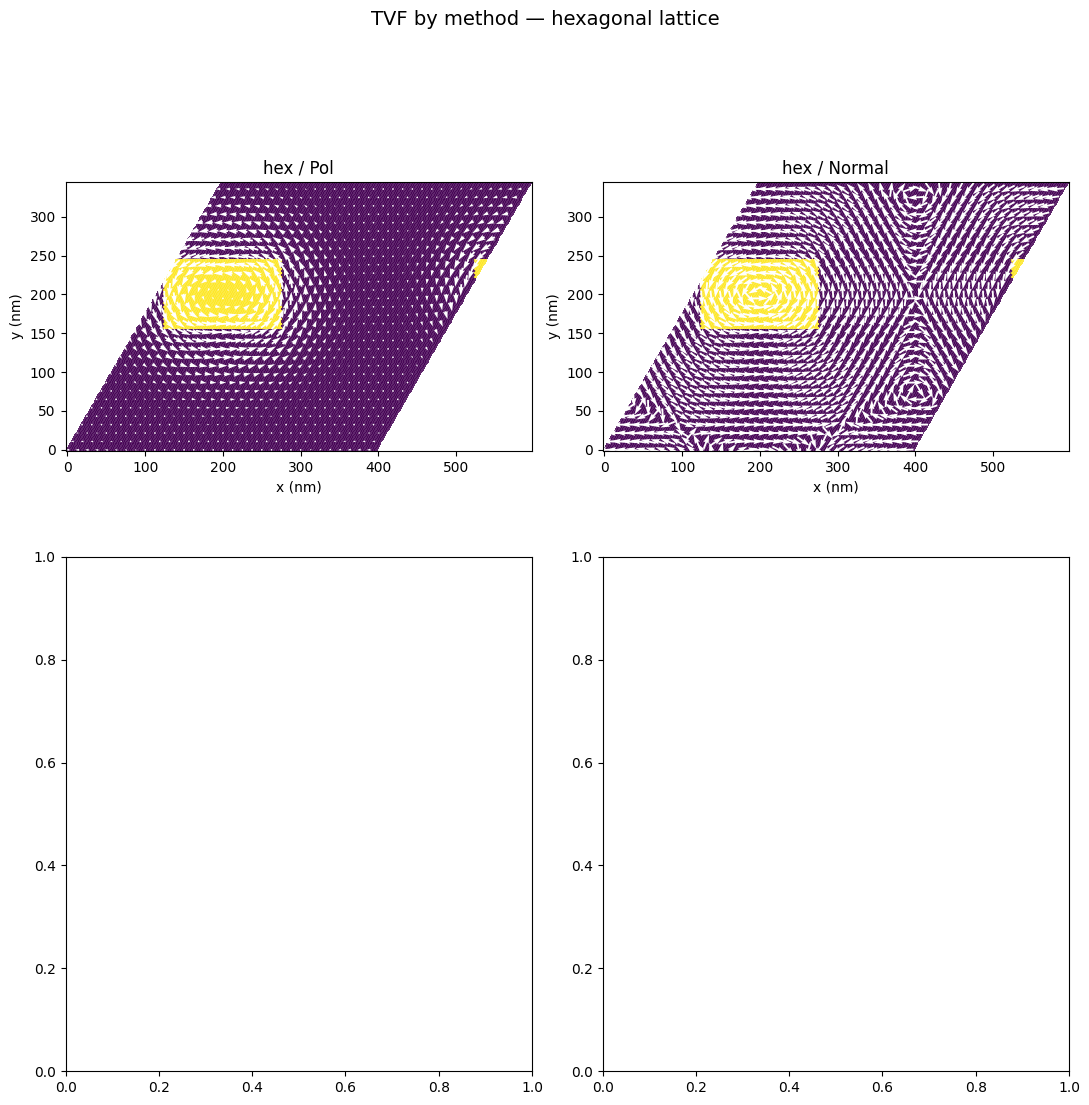

In [14]:
lattice_h = Lattice.hexagonal(P)
eps_h, a1_h, a2_h = build_eps(lattice_h)

fig, axes = plt.subplots(2, 2, figsize=(11, 11))
for ax, method in zip(axes.ravel(), METHODS):
    tvf = TVF(a1_h, a2_h, M=M, N=N, method=method, optimizer='newton')
    Tx, Ty = tvf.compute(eps_h.to(device='cuda'), alpha=1.0, beta=0.05, gamma=0.0, steps=1)
    plot_tvf(eps_h[0], Tx[0], Ty[0], lattice_h, title=f"hex / {method}", ax=ax)
fig.suptitle("TVF by method — hexagonal lattice", y=1.0, fontsize=14)
plt.tight_layout(); plt.show()

## Things to try

- **Shape:** swap `Ellipse` for `Cross(center, length, width, angle, ...)`,
  `Star(center, n, outer_radius, inner_radius, ...)`, or `Rectangle(center, size, angle)`.
  Combine with `.union()` / `.difference()` / `.rotate()` on `Shape`.
- **Materials:** any of `list_materials()` (e.g. `material("TiO2")`, `material("Au")`)
  or `ConstantEps(value)` / `ConstantIndex(n)` for the solid/void.
- **Dispersion:** sweep `WL` and watch `Re(eps)`/`Im(eps)` change (lossy metals like Au).
- **Truncation / loss:** raise `M, N` (need `2M+1<=Nx`, `2N+1<=Ny`); sweep
  `alpha` (alignment), `beta` (Fourier reg.), `gamma` (smoothness), `steps`.
- **Ellipse map:** tune `step` / `fill_frac` in `plot_jones_ellipses`; run it on
  `"Jones_direct"` to compare, or on `"Pol"`/`"Normal"` to see the linear (line) limit.